In [1]:
from pathlib import Path
import pandas as pd

table_pkl_dim2 = Path("~/t7ssd/classification_results_consistent_features/dim2/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim2)

In [2]:
group_cols = [
    "dimension",
    "sampling_strategy",
    "sample_size_per_dim",
    "n_instances_train",
    "n_runs_train",
    "n_feval_train",
]

# aggregate over the 5 folds
fold_agg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        acc_mean=("accuracy_median", "mean"),
        acc_sd=("accuracy_median", "std"),
        acc_allruns_mean=("accuracy_allruns", "mean"),
        consistency_mean=("consistency", "mean"),
        cv_instance_median_mean=("cv_instance_median_mean", "first"),
        cv_instance_median_median=("cv_instance_median_median", "first"),
        cv_function_median_mean=("cv_function_median_mean", "first"),
        cv_function_median_median=("cv_function_median_median", "first"),
        # feature meta‑info (optional)
        # n_features=("n_features", "first"),
        # n_omitted_features=("n_omitted_features", "first"),
        # omitted_features=("omitted_features", "first"),
    )
)

In [3]:
df.columns


Index(['dimension', 'sampling_strategy', 'sample_size_per_dim',
       'n_instances_train', 'n_runs_train', 'n_feval_train', 'fold',
       'n_features', 'n_omitted_features', 'omitted_features',
       'cv_instance_median_mean', 'cv_instance_median_median',
       'cv_function_median_mean', 'cv_function_median_median',
       'cv_training_folds_median_mean', 'cv_training_folds_median_median',
       'accuracy_median', 'accuracy_allruns', 'consistency'],
      dtype='str')

In [4]:
pd.qcut(df["n_feval_train"], q=4).value_counts()

n_feval_train
(1199.999, 14400.0]    900
(14400.0, 36000.0]     850
(77700.0, 480000.0]    800
(36000.0, 77700.0]     650
Name: count, dtype: int64

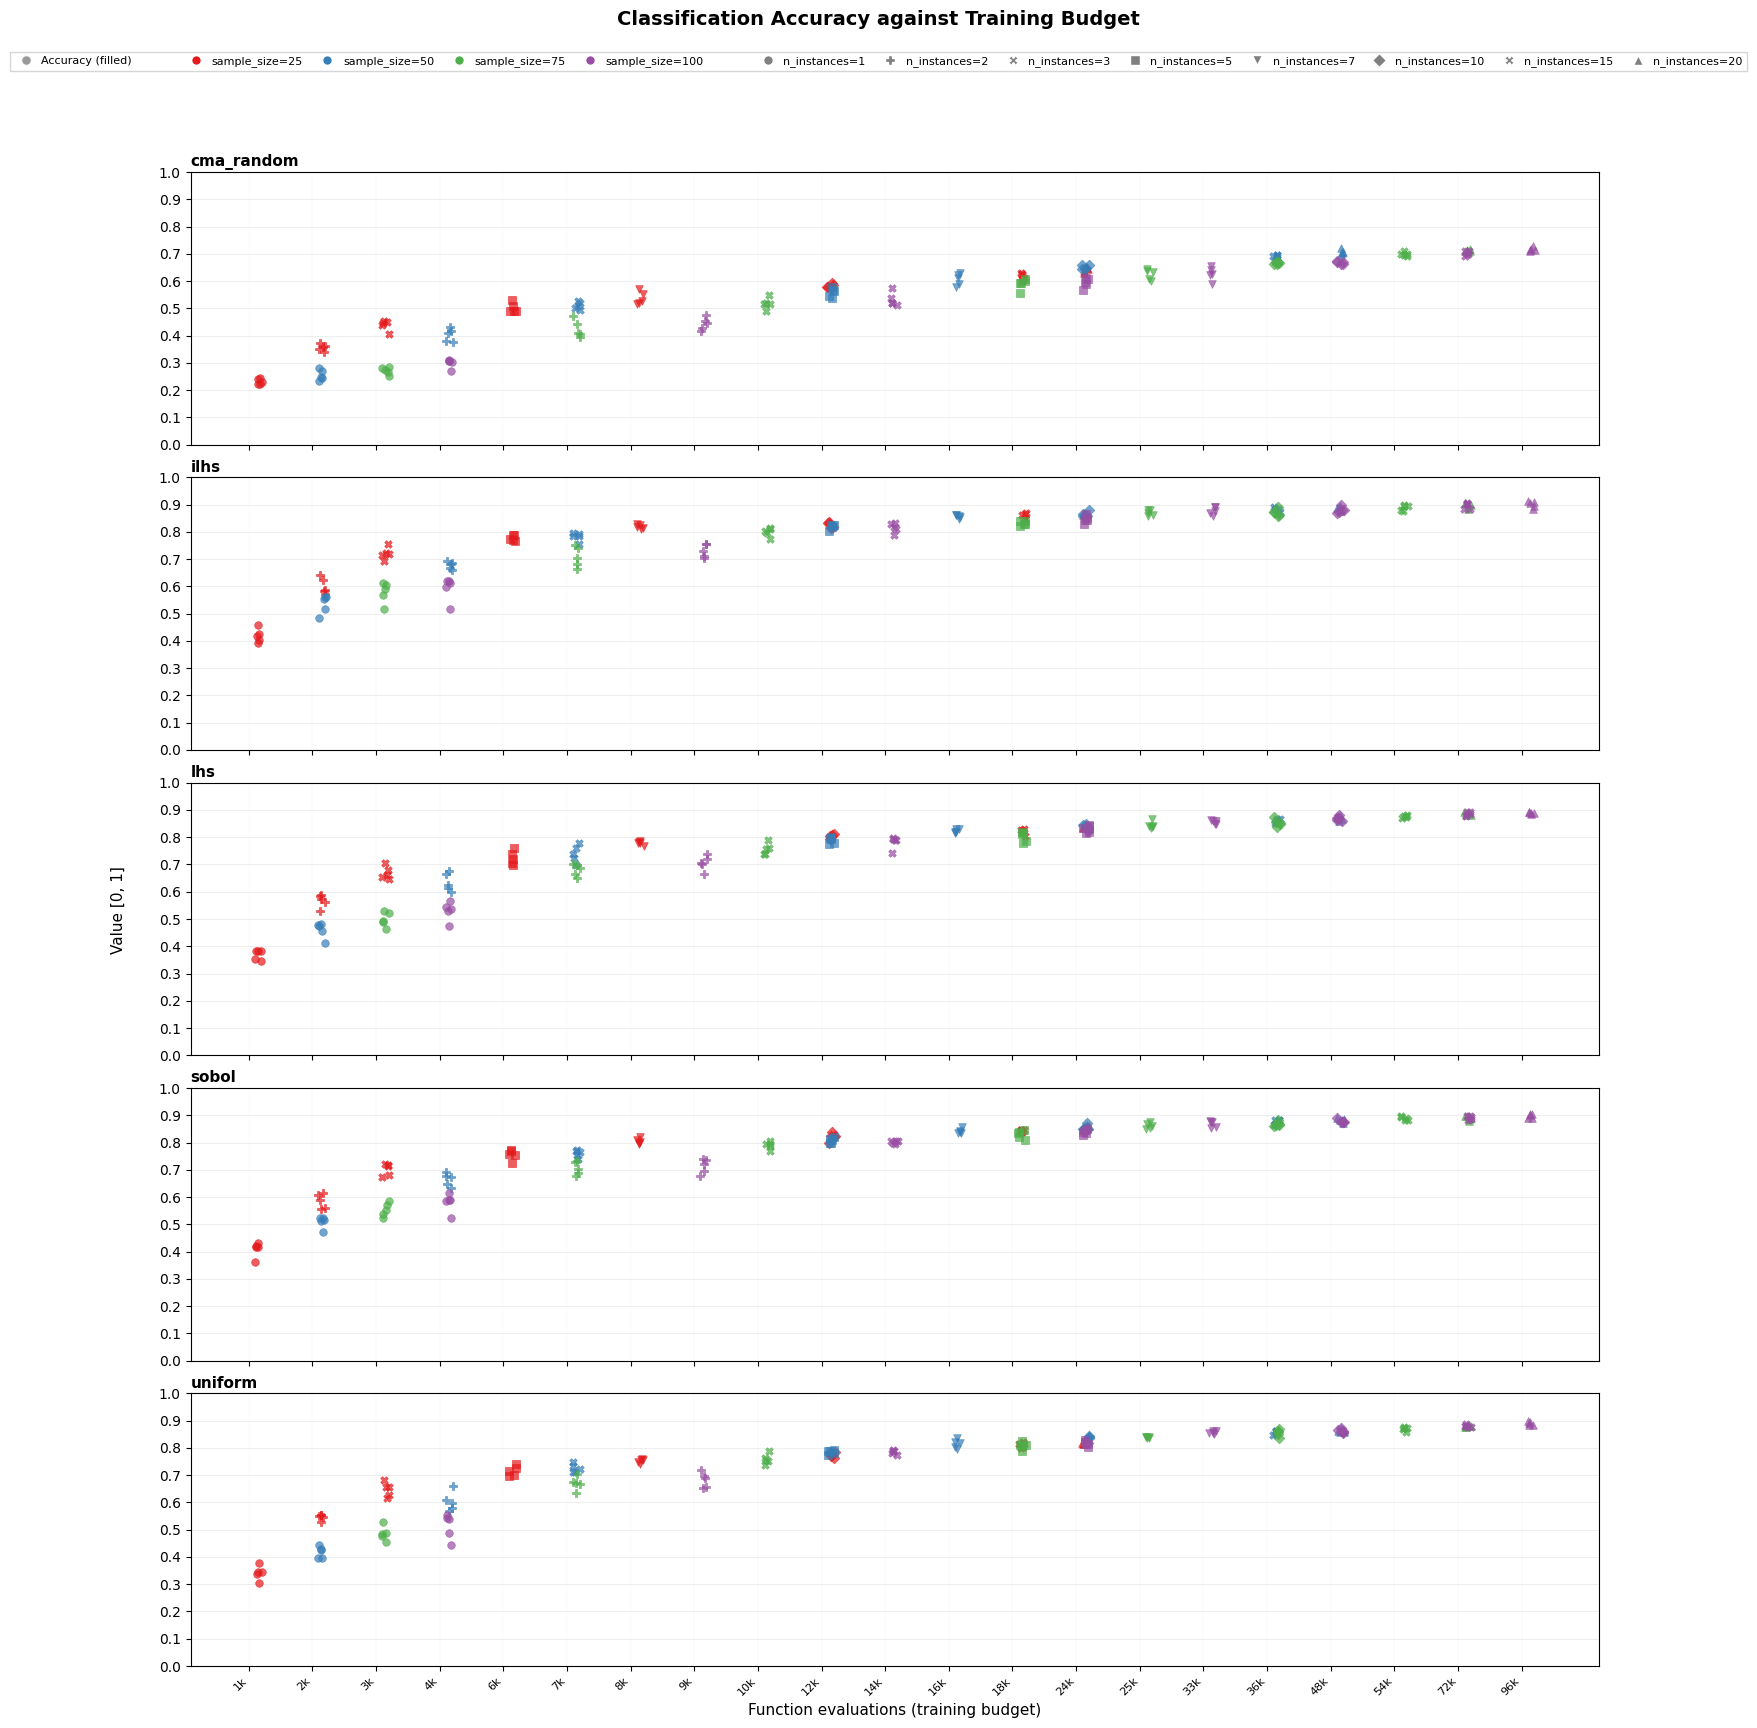

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [5]:
from ela_table_helper import *
plot_cv_vs_accuracy(df[df.n_runs_train == 1])


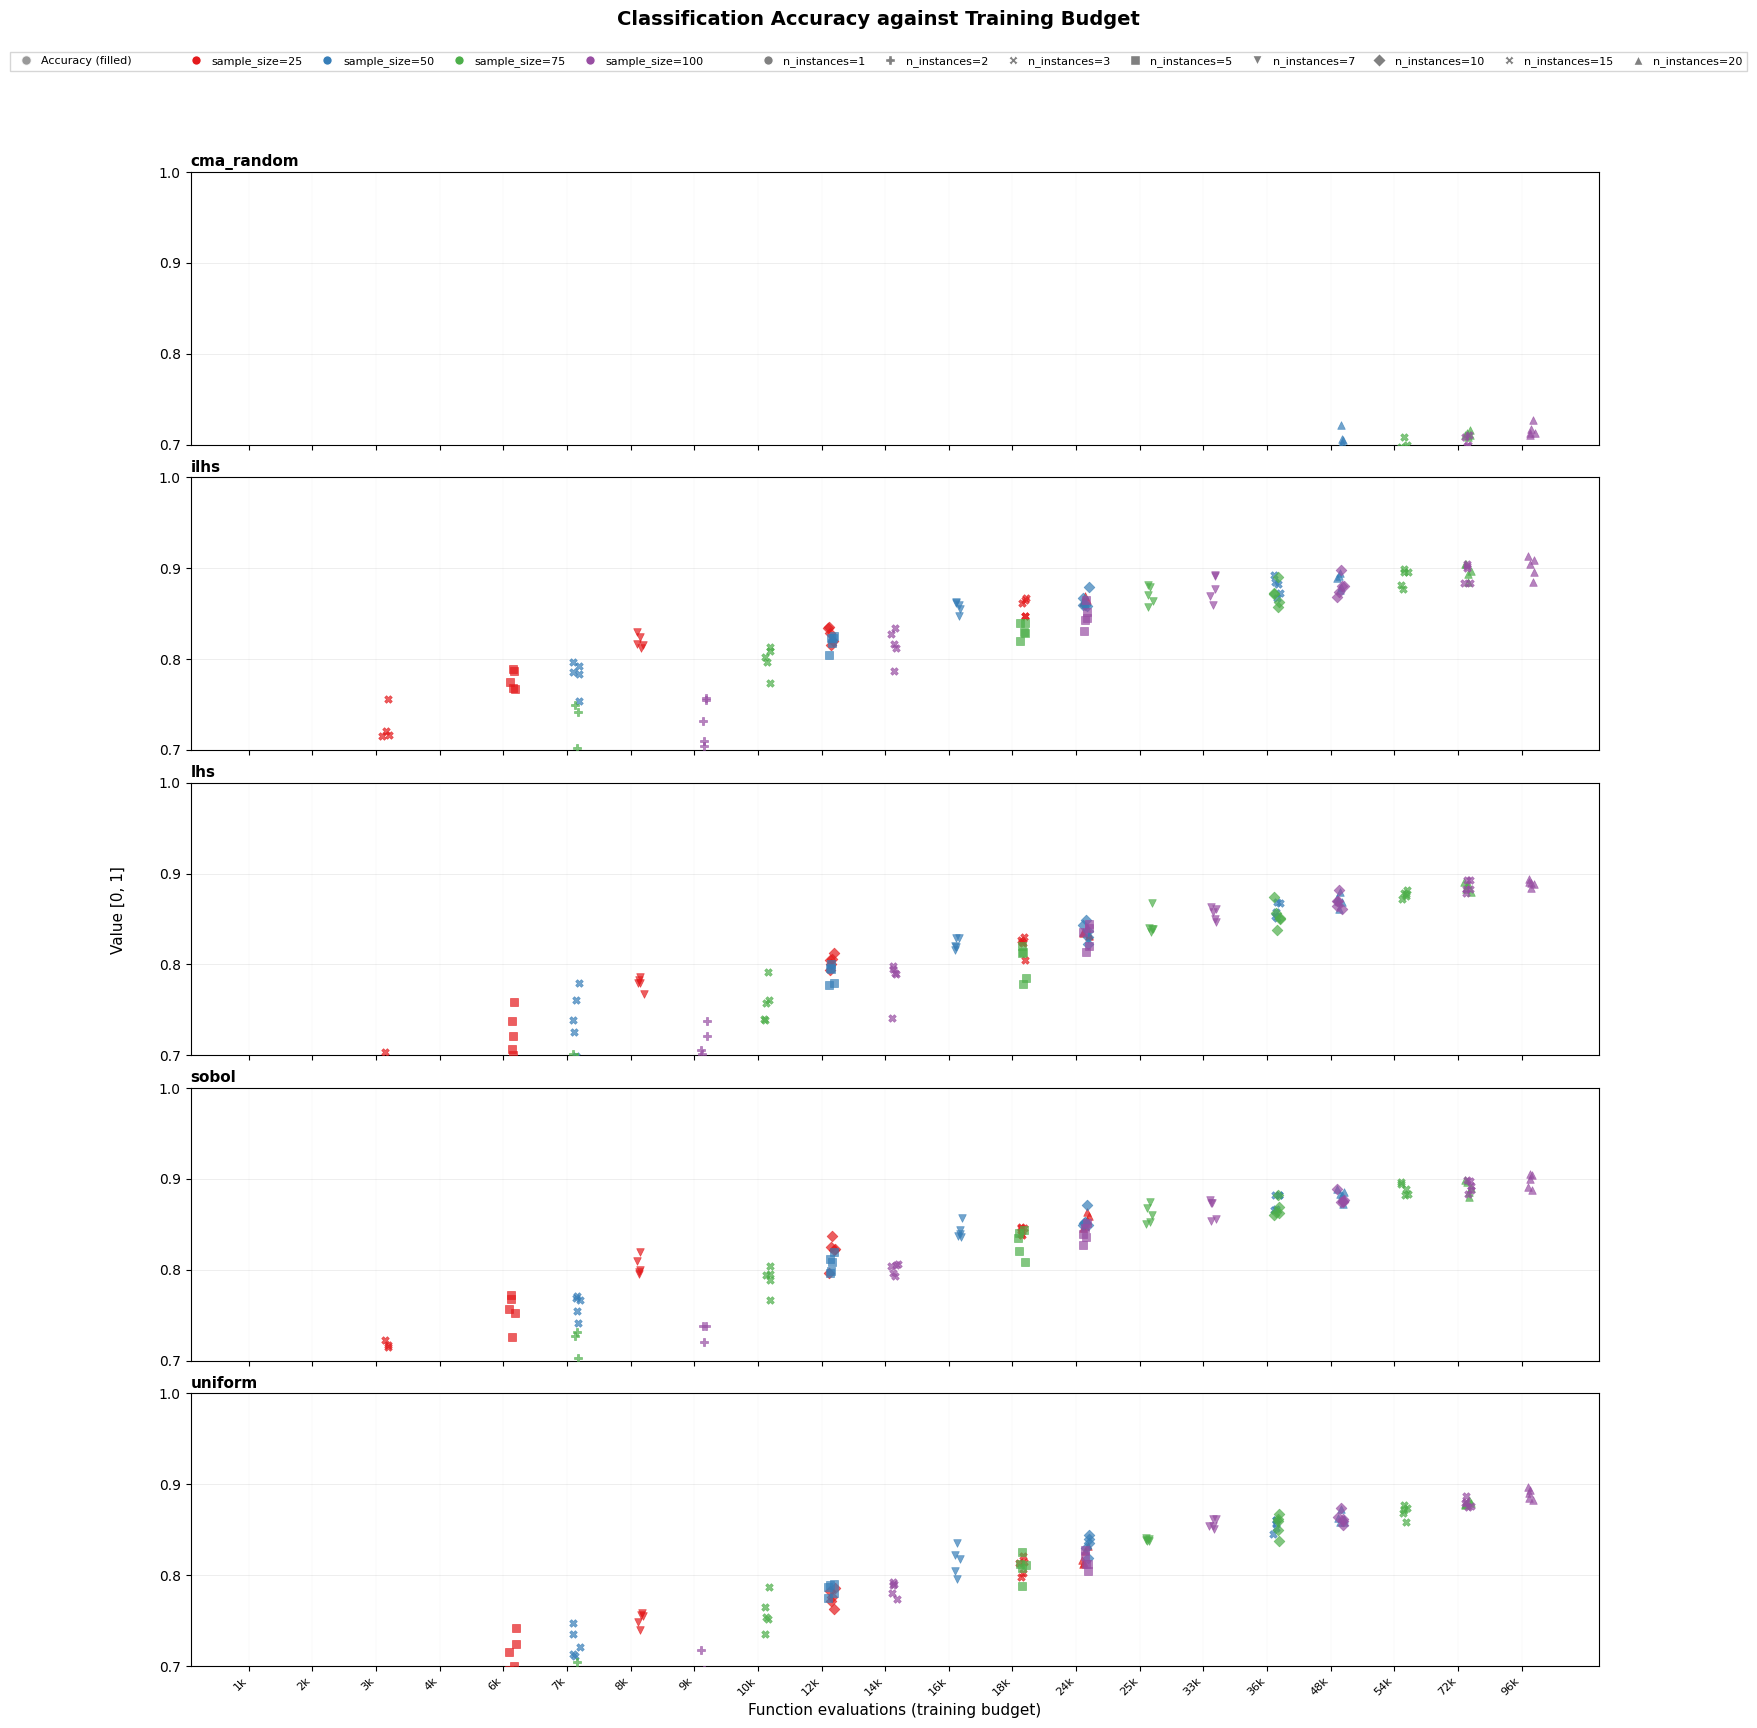

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [6]:
plot_cv_vs_accuracy(df[df.n_runs_train == 1], ylim=(0.7, 1.0))

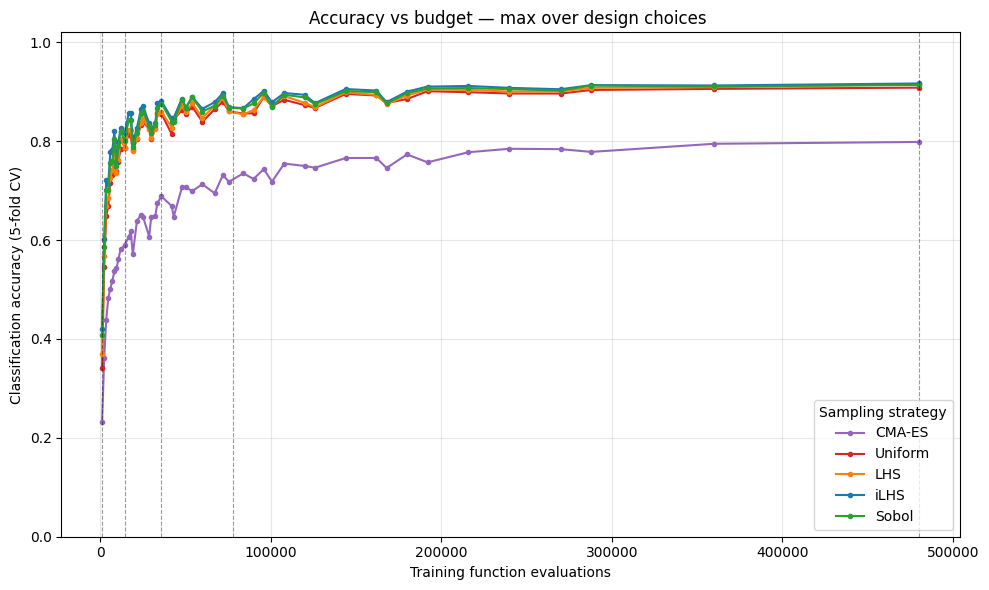

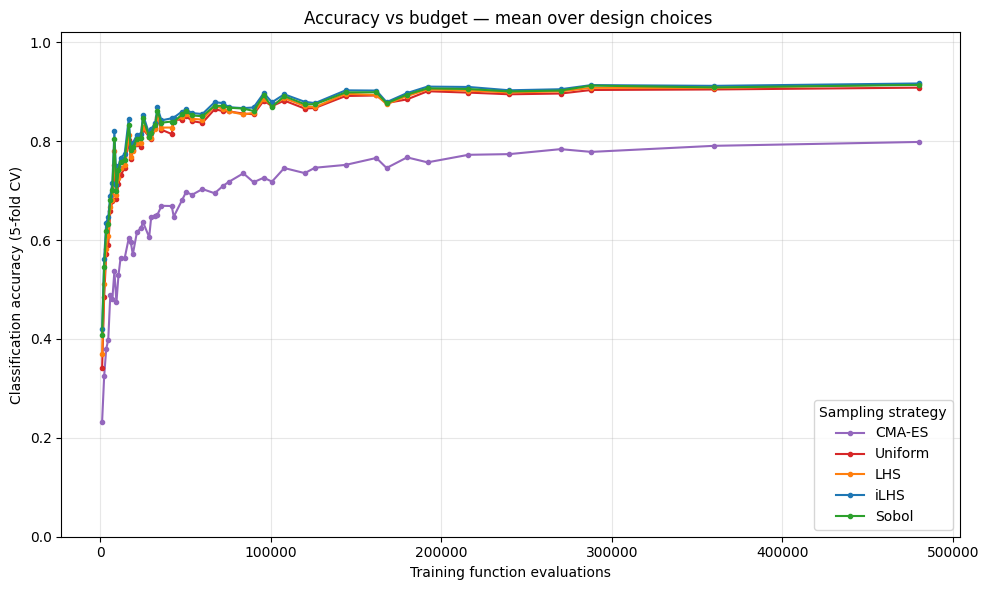

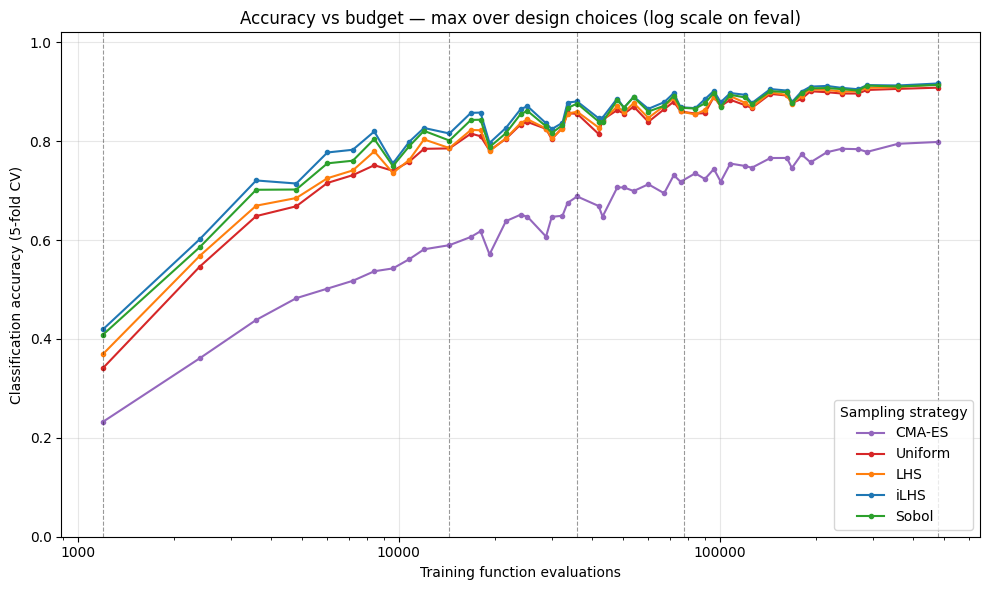

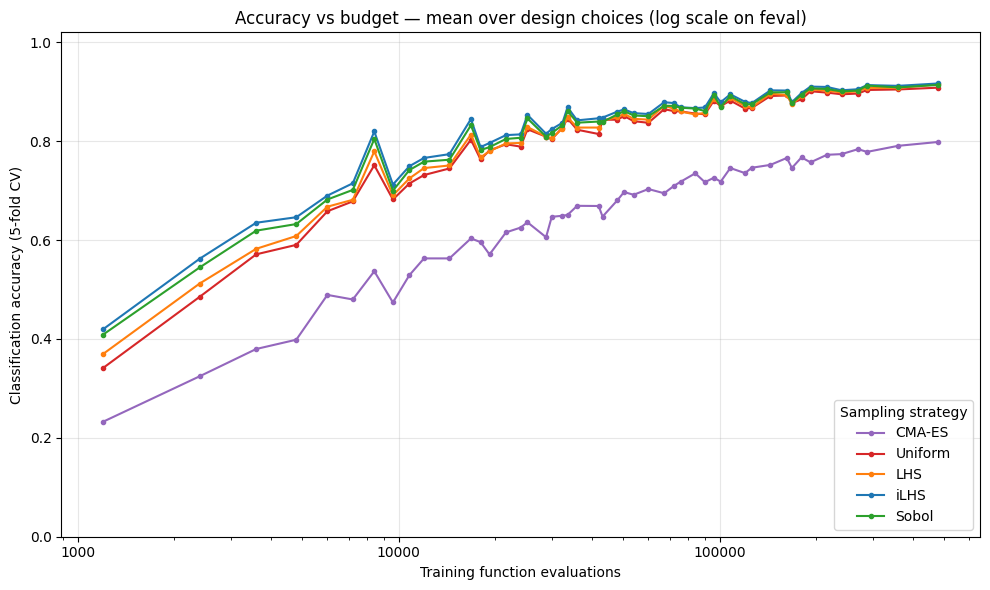

In [7]:
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean")
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4, log_scale=True)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean", log_scale=True)

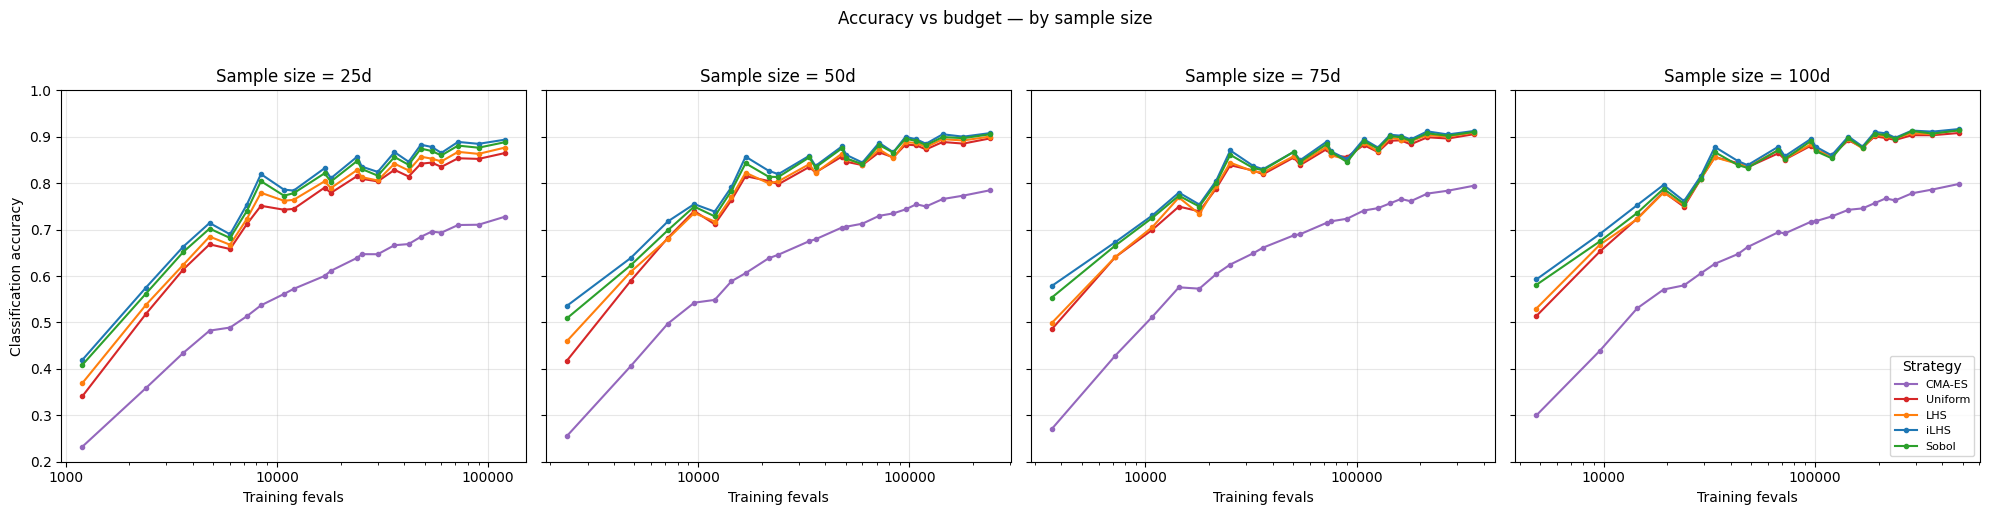

In [8]:
plot_accuracy_vs_budget_faceted(fold_agg_df, ylim = (0.2, 1.0))


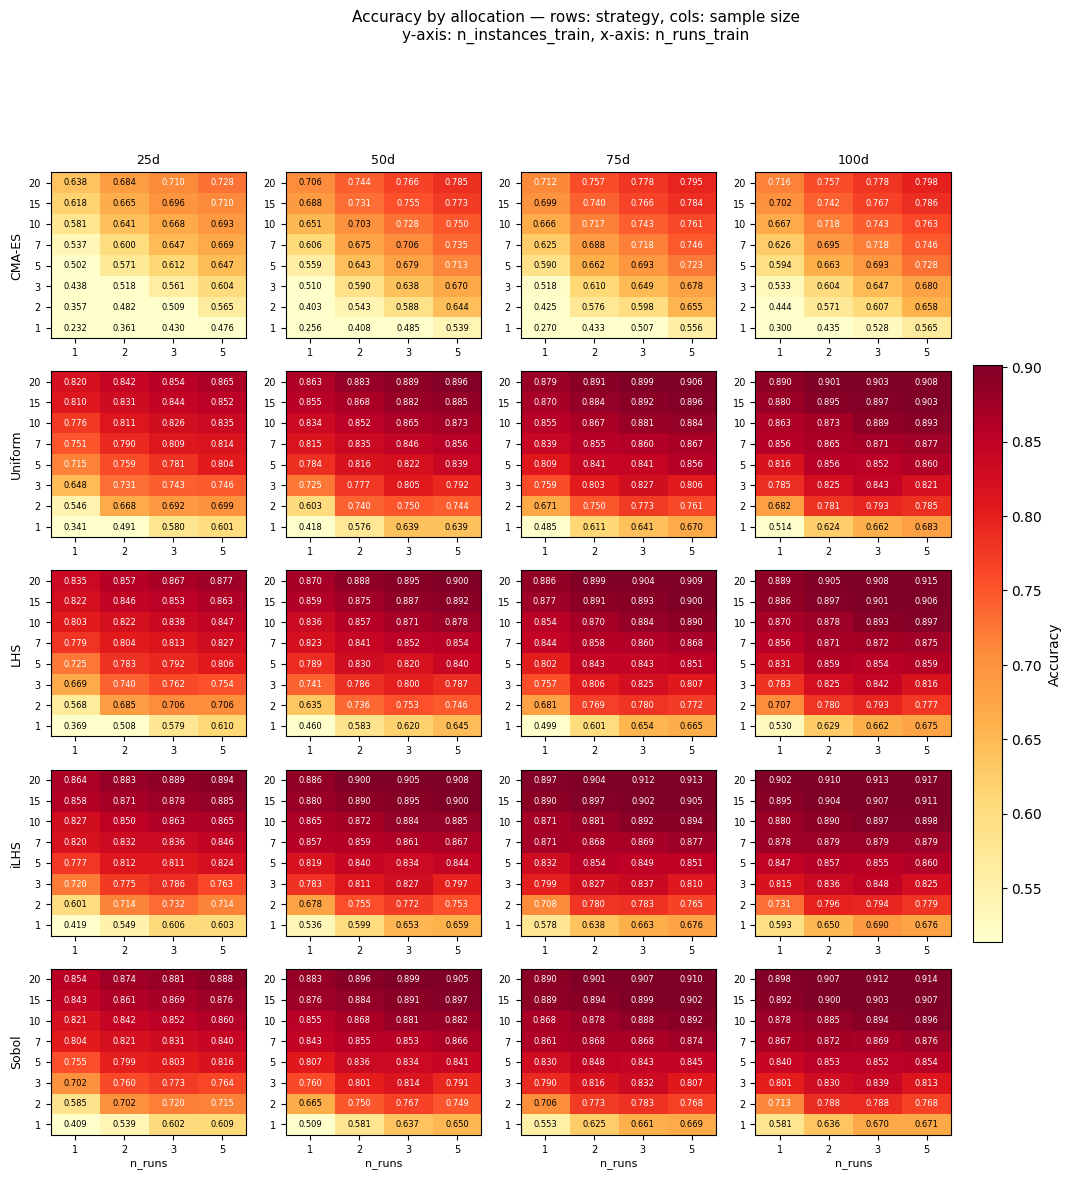

In [9]:
plot_allocation_heatmaps(fold_agg_df)


In [10]:
# from rq2_factor_importance import *
# imp_df = run_all(fold_agg_df, metric="acc_allruns_mean")

In [11]:
# from rq2_cv_accuracy import *
# run_all(fold_agg_df, cv_col="cv_instance_median_mean",
#                                acc_col="acc_allruns_mean")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Saturation curves for Strategy ...


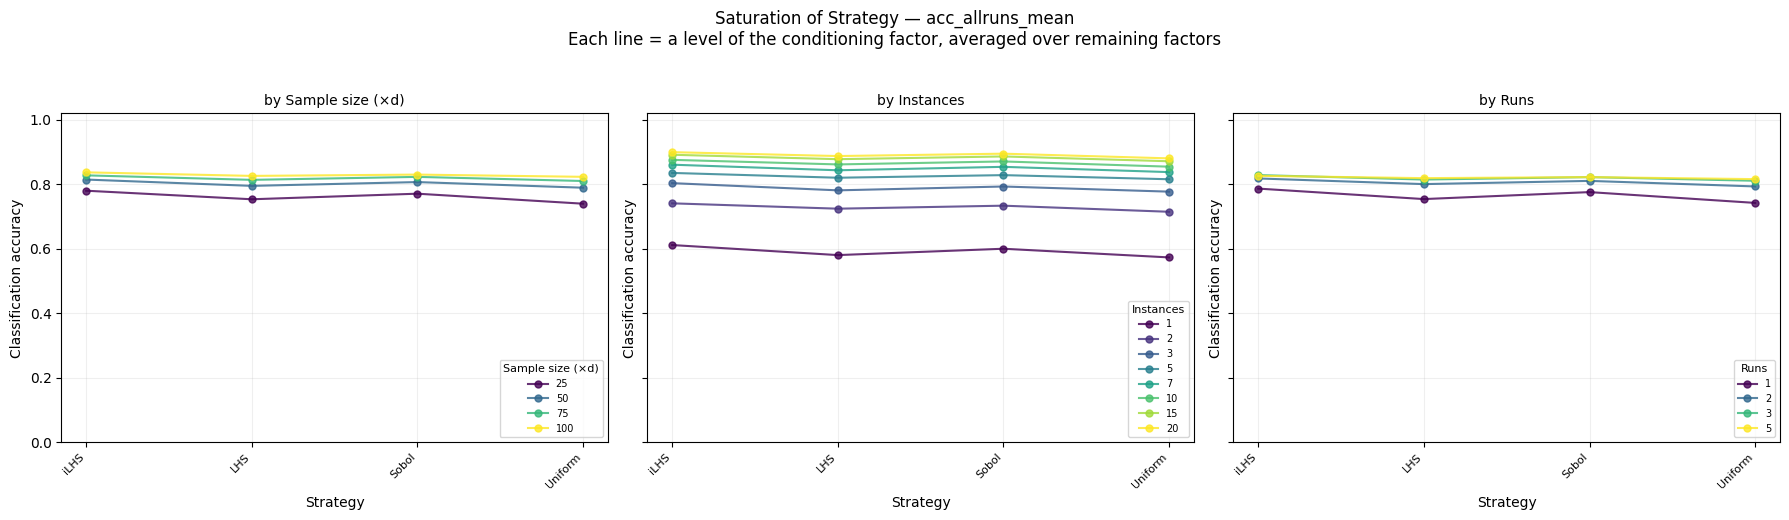

Saturation curves for Sample size (×d) ...


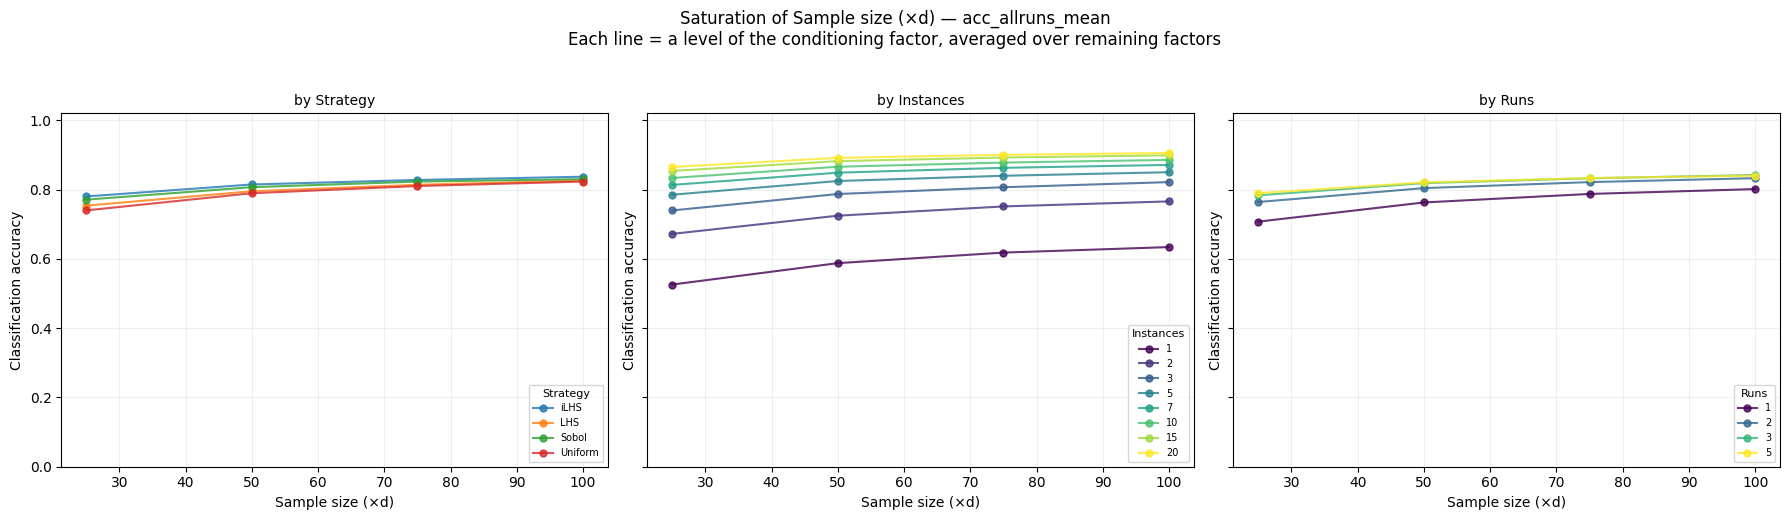

Saturation curves for Instances ...


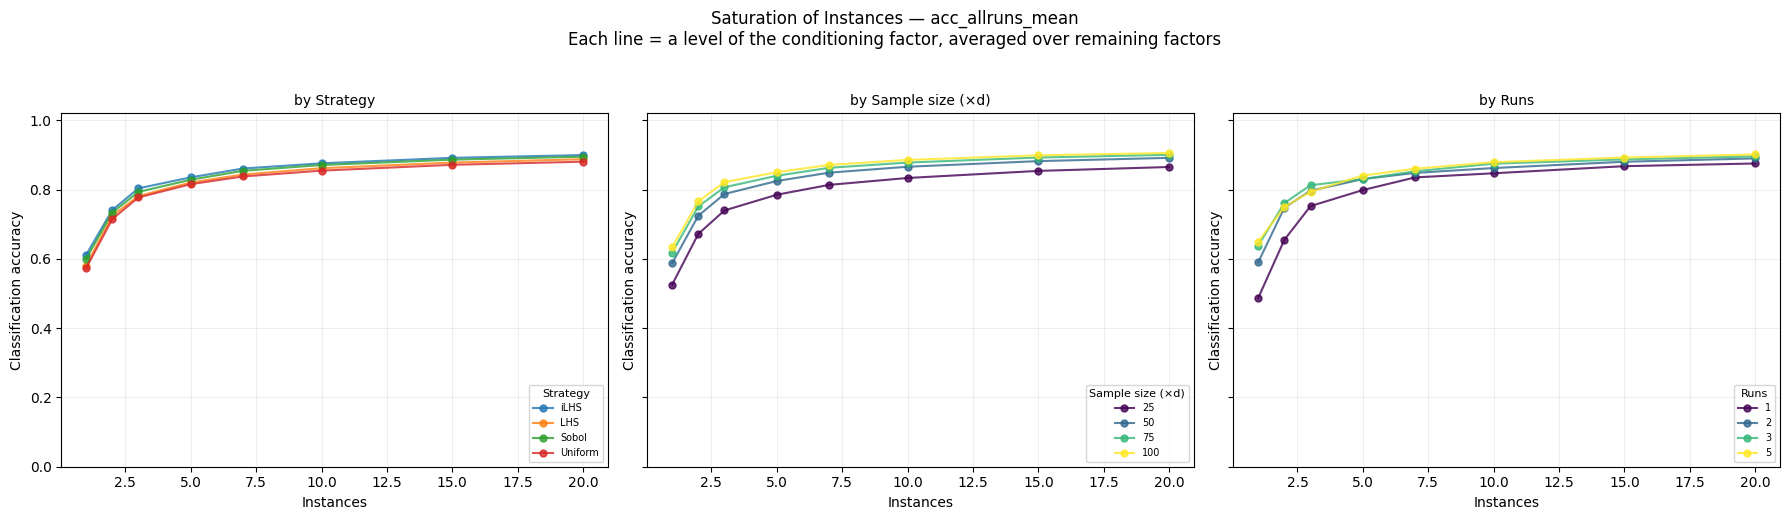

Saturation curves for Runs ...


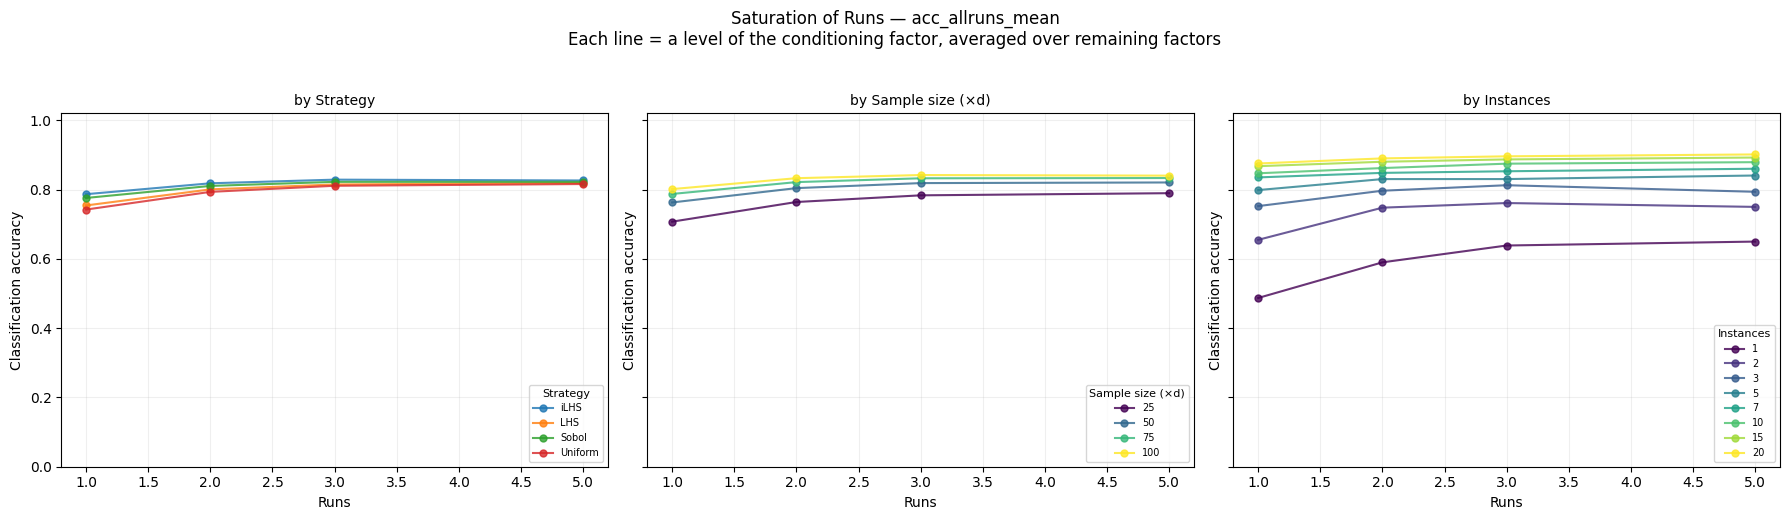

Marginal gains per step ...
          factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
Sample size (×d)          25        50   0.040450    0.068005          59.481026
Sample size (×d)          50        75   0.017142    0.068005          25.207344
Sample size (×d)          75       100   0.010413    0.068005          15.311630
       Instances           1         2   0.137104    0.299313          45.806114
       Instances           2         3   0.060340    0.299313          20.159415
       Instances           3         5   0.036139    0.299313          12.074021
       Instances           5         7   0.024135    0.299313           8.063316
       Instances           7        10   0.016679    0.299313           5.572586
       Instances          10        15   0.016096    0.299313           5.377695
       Instances          15        20   0.008820    0.299313           2.946853
            Runs           1         2   0.040924    0.056166          72.863494


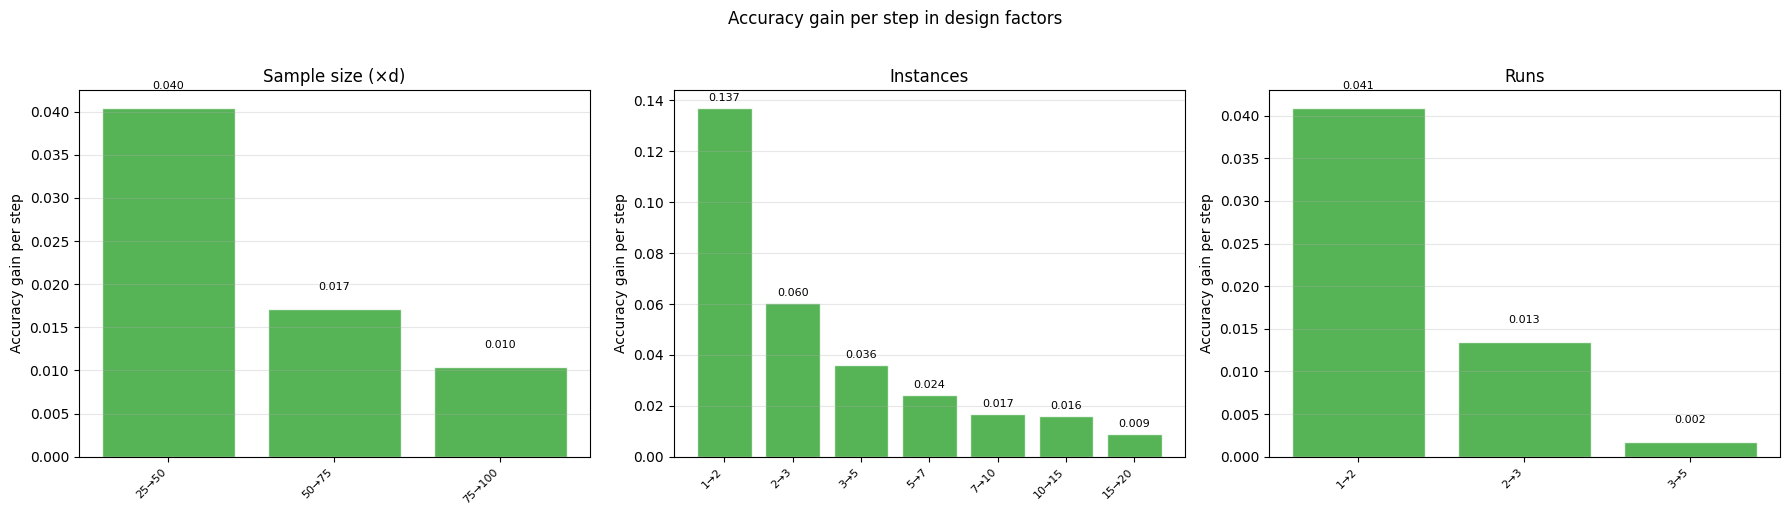

In [12]:
from rq2_saturation_curves import *

# All four factors + marginal gains table
gains_df = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Overall saturation by tier: Strategy ...


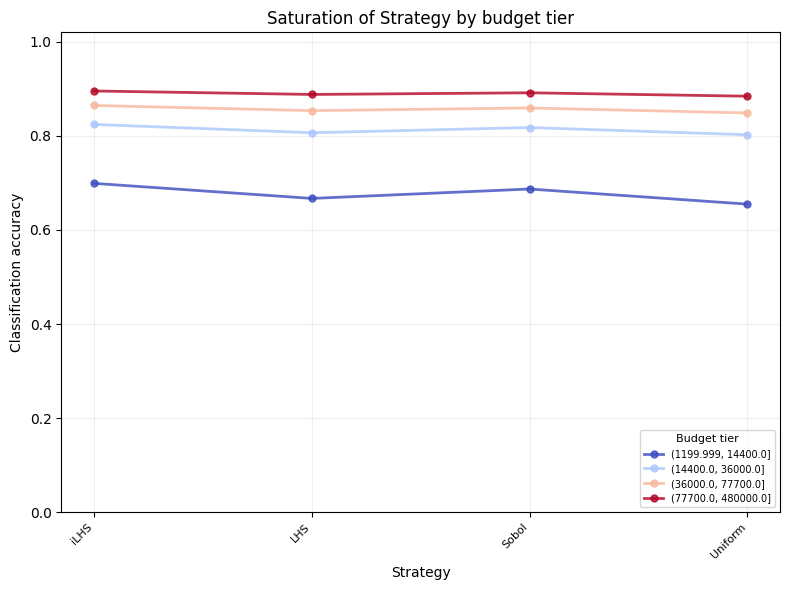

Overall saturation by tier: Sample size (×d) ...


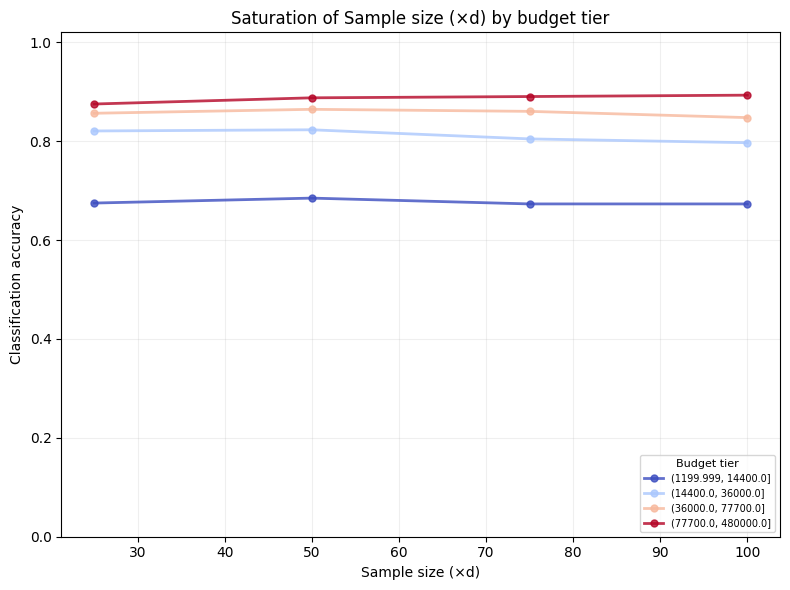

Overall saturation by tier: Instances ...


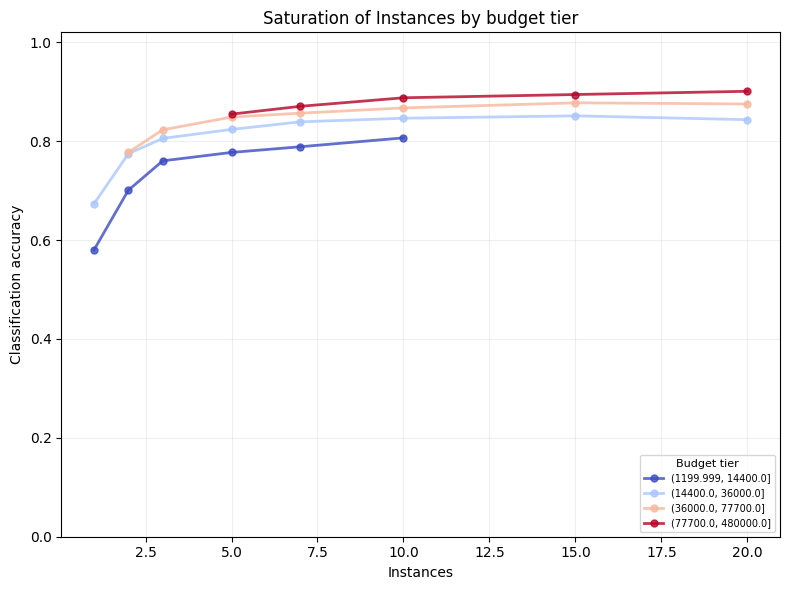

Overall saturation by tier: Runs ...


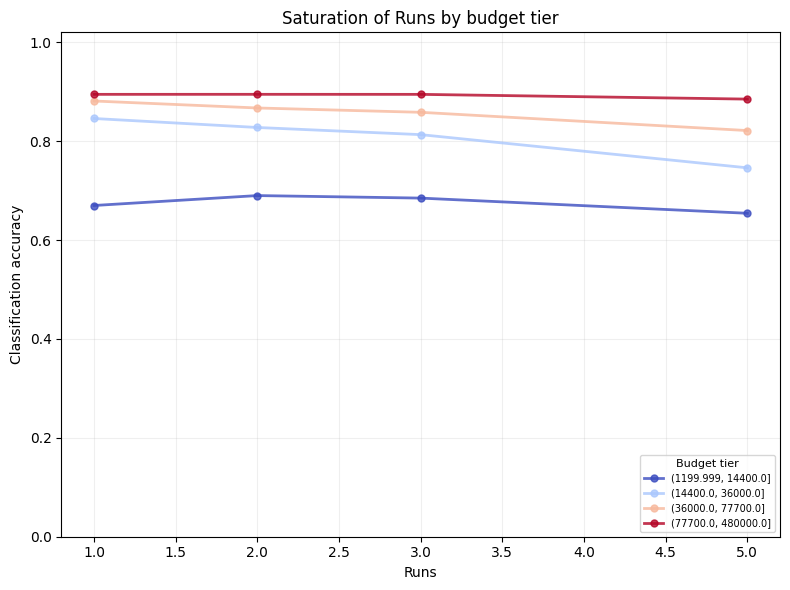

Per-tier saturation: Strategy ...


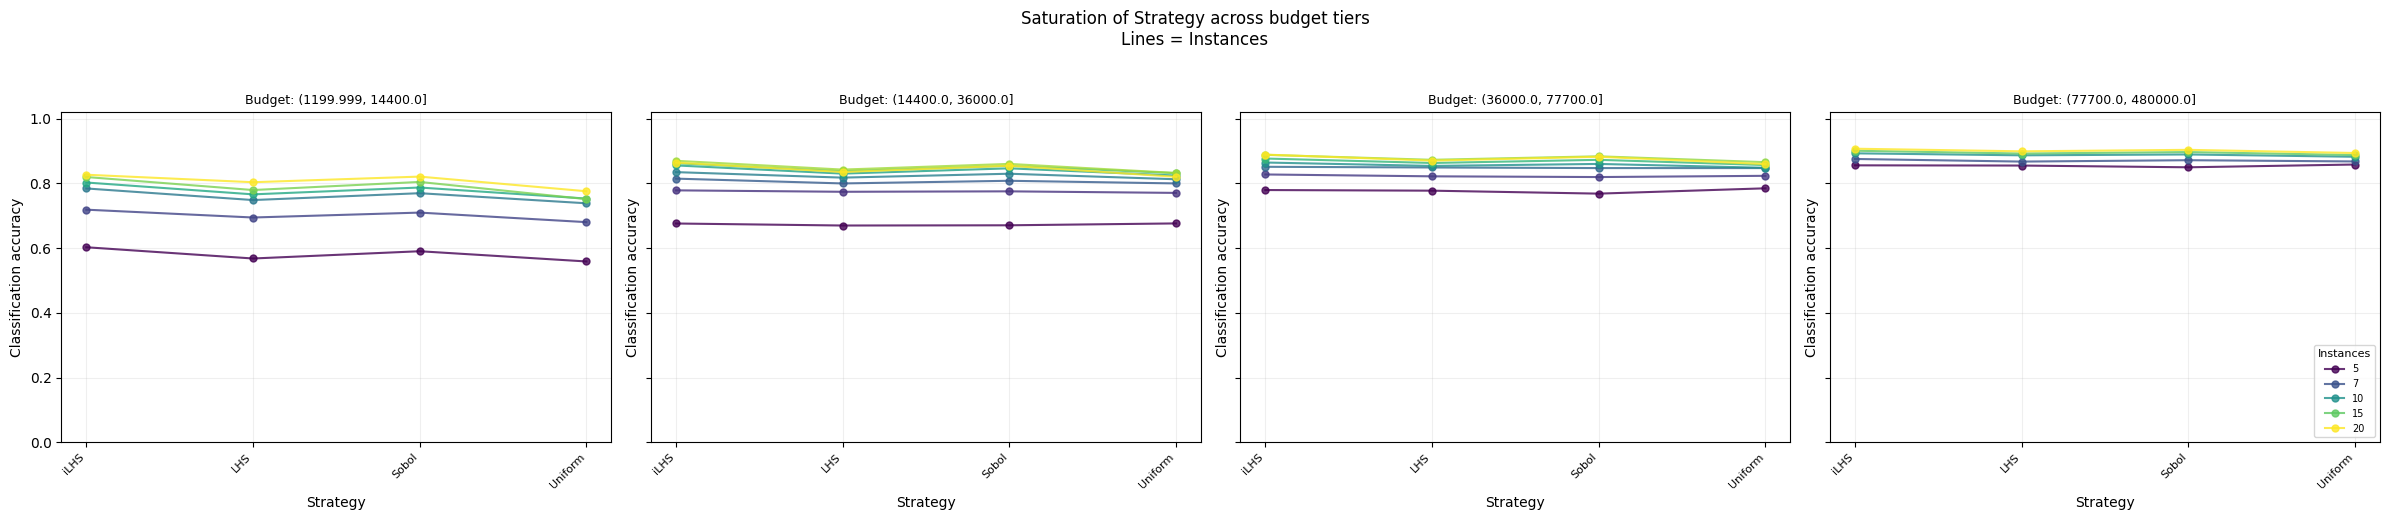

Per-tier saturation: Sample size (×d) ...


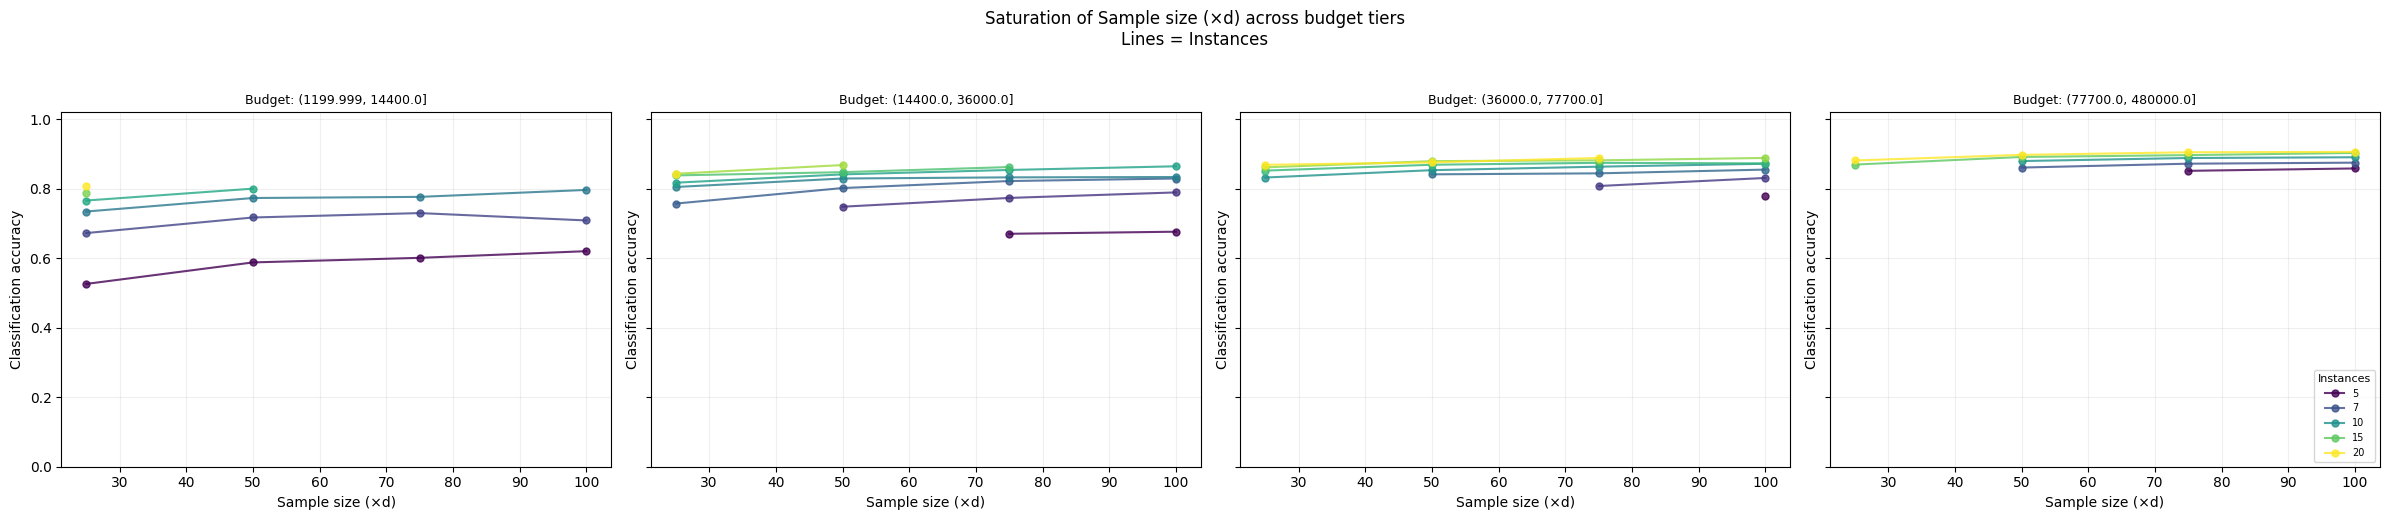

Per-tier saturation: Instances ...


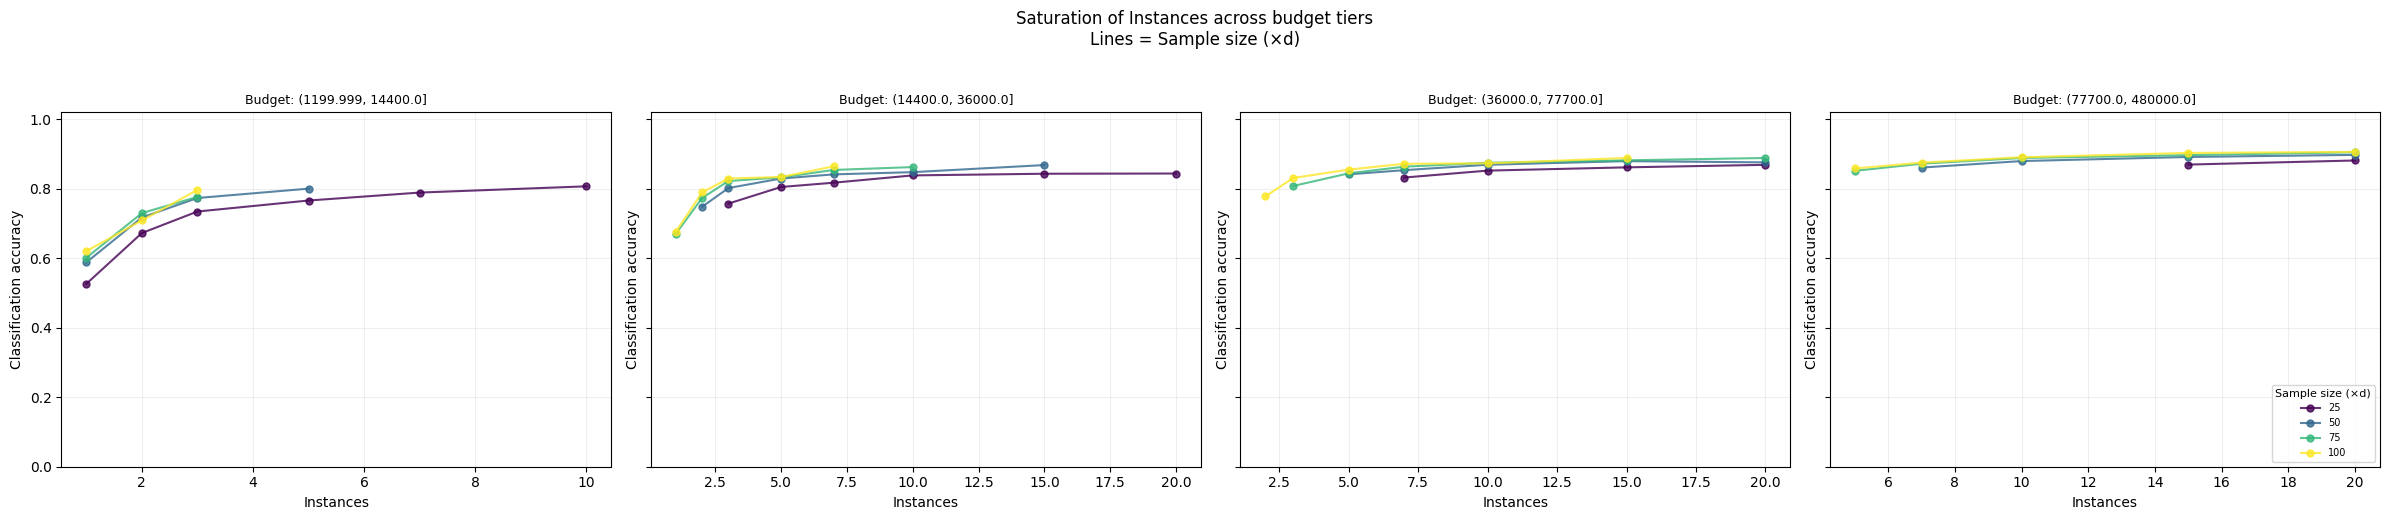

Per-tier saturation: Runs ...


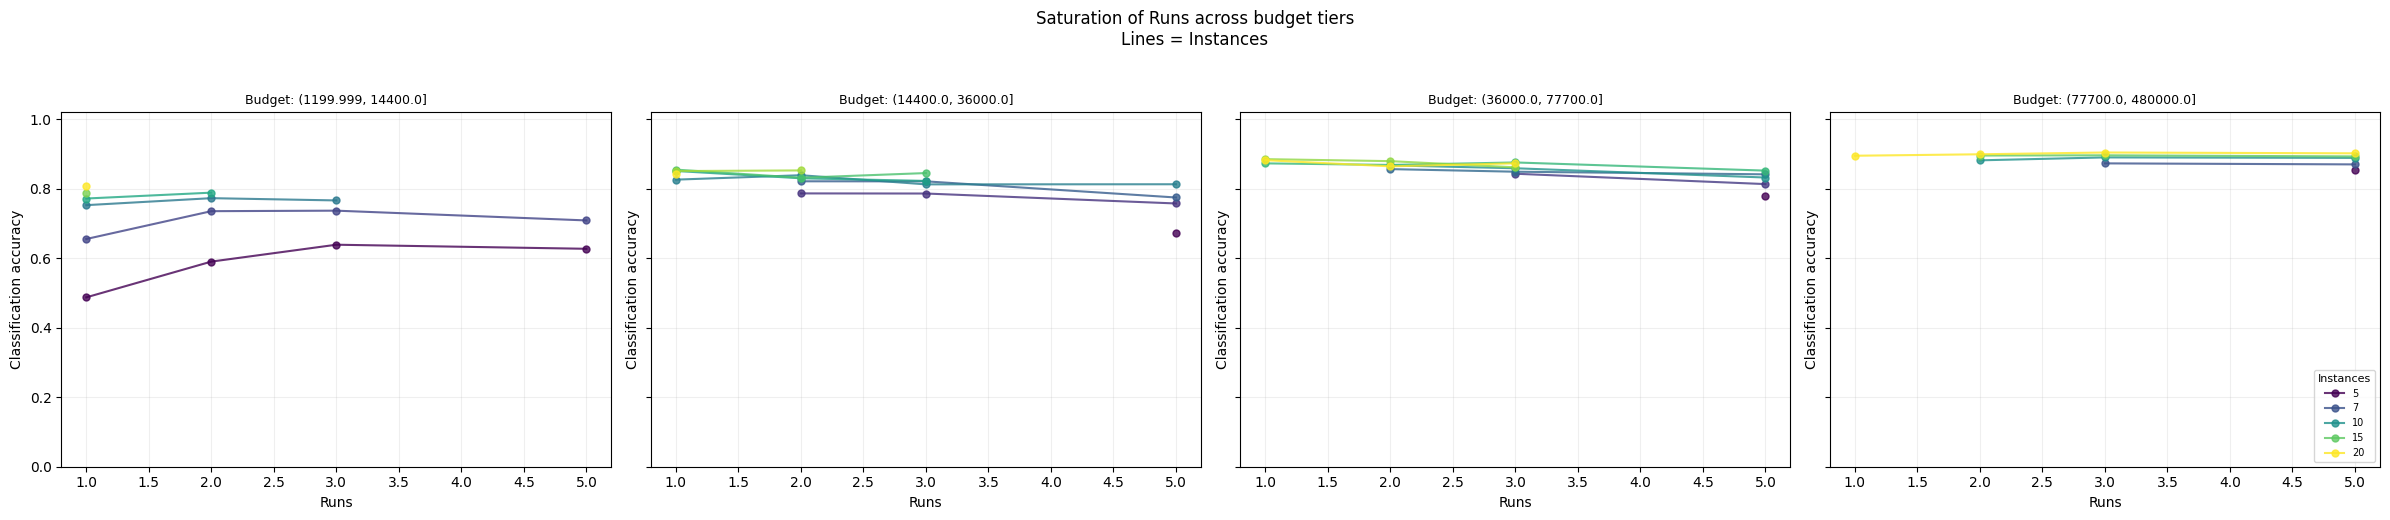

Marginal gains by tier ...
        budget_tier           factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
(1199.999, 14400.0] Sample size (×d)          25        50   0.010000   -0.001786        -559.790074
(1199.999, 14400.0] Sample size (×d)          50        75  -0.011752   -0.001786         657.857652
(1199.999, 14400.0] Sample size (×d)          75       100  -0.000035   -0.001786           1.932422
(1199.999, 14400.0]        Instances           1         2   0.120906    0.226804          53.308443
(1199.999, 14400.0]        Instances           2         3   0.059400    0.226804          26.189847
(1199.999, 14400.0]        Instances           3         5   0.017031    0.226804           7.509028
(1199.999, 14400.0]        Instances           5         7   0.011471    0.226804           5.057834
(1199.999, 14400.0]        Instances           7        10   0.017997    0.226804           7.934848
(1199.999, 14400.0]             Runs           1         2   0.0

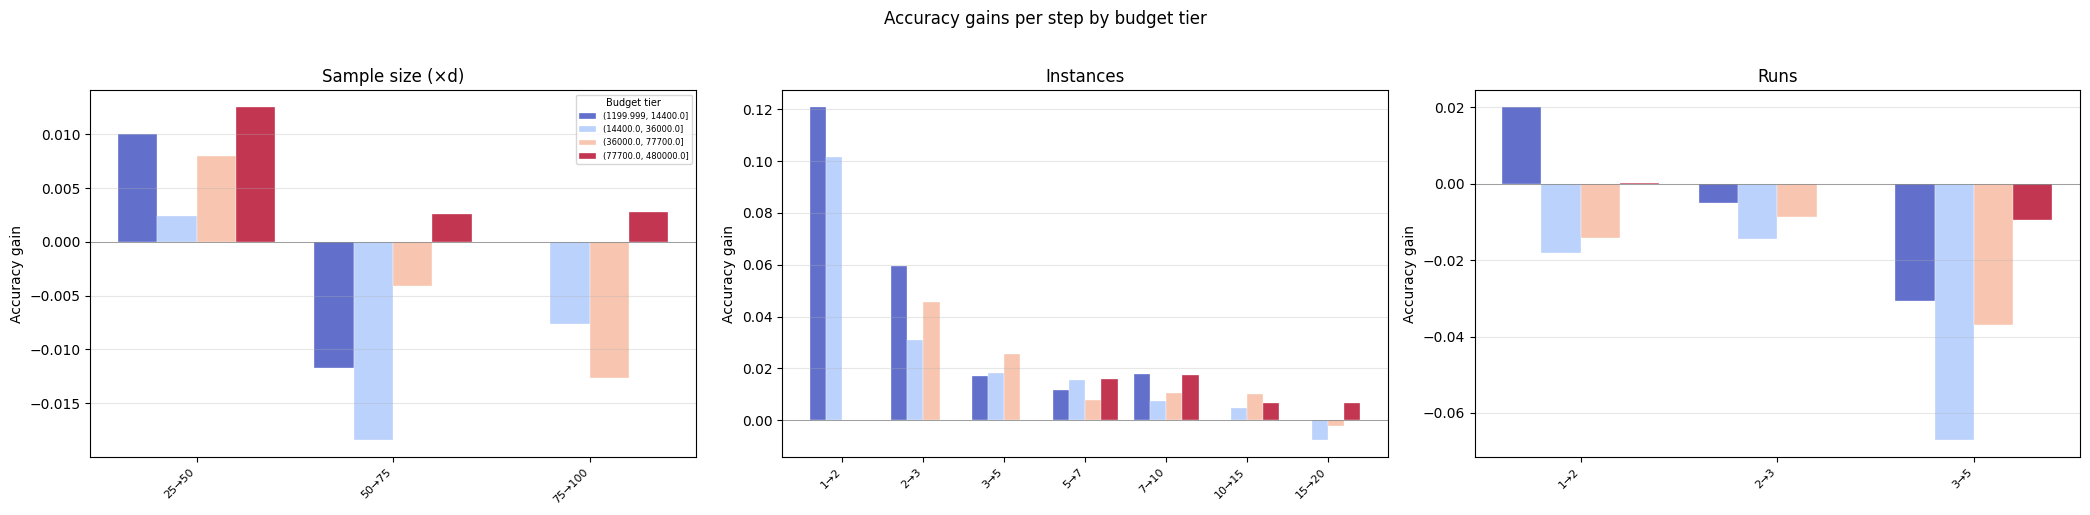

In [13]:
gains_by_tier = run_by_tier(fold_agg_df, metric="acc_allruns_mean",
                             omit_strategies="cma_random", n_tiers=4)